In [1]:
from transformers import AutoModelForImageTextToText, AutoProcessor
import torch
from PIL import Image
from datasets import load_dataset
import sys

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


In [2]:
module_path = "/home/ubuntu/Shree_FYP"

In [3]:
sys.path.append(module_path)

In [4]:
from data.stage_1_datasets_static import build_static_dataset

I0000 00:00:1781148474.336155  108323 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781148474.561446  108323 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781148477.334634  108323 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [5]:
model = AutoModelForImageTextToText.from_pretrained(
    "shreethar/stage1_unsloth",
    dtype = torch.bfloat16,
    device_map = "cuda"
)

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

In [56]:
processor = AutoProcessor.from_pretrained("shreethar/stage1_unsloth")

In [7]:
molmoact_hf_ds = load_dataset("allenai/MolmoAct-Pretraining-Mixture", "auxiliary_trace")["train"]
# 2. Pass it to your dataset builder
splits = build_static_dataset(molmoact_hf_ds=molmoact_hf_ds)

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/278 [00:00<?, ?it/s]

Building static VLA dataset...
  MolmoAct: 195,622 records
  ShareRobot Affordance: 6,522 records
  ShareRobot Planning: 20,568 records
  RoboVQA: 99,956 records (from 195,818 QA pairs)
  RoboFAC: 48,993 records

Dataset split summary:
  train:  320,240  (86.2%)
  test :   51,421  (13.8%)
  total:  371,661


In [8]:
# 3. Access your splits
train_dataset = splits["train"]
test_dataset = splits["test"]

In [9]:
sample = train_dataset[1]

In [24]:
bkp = sample["messages"][0]['content'][1]['text']

In [23]:
sample["messages"][0]['content'][1]['text']

"You are a robot manipulation assistant. Given an observation image and a task instruction, predict the end-effector's 2D trajectory as 5 distinct waypoints showing the continuous movement from the start to the target. If reasoning, provide a single concise plan: identify the start, locate the target, and interpolate the path. Do NOT loop, endlessly refine, or re-evaluate. Finally, output the coordinate list exactly once in this exact format: [[x1,y1],[x2,y2],[x3,y3],[x4,y4],[x5,y5]]\n\nTask: The task is place the ceramic cup in the ceramic bowl. What is the trajectory that the end effector should take?"

In [64]:
STAGE2_TRAJ_SYSTEM = (
    "You are a robot manipulation assistant. "
    "Given an observation image and a task instruction, predict the "
    "end-effector's 2D trajectory as 5 waypoints.\n\n"
    "Think through the task, then output the coordinate list inside answer tags:\n"
    "[[x1,y1],[x2,y2],[x3,y3],[x4,y4],[x5,y5]]\n\n"
    "Coordinates are 0-1000 integers (0=top-left, 1000=bottom-right).\n\n"
    "Task: The task is place the ceramic cup in the ceramic bowl. What is the trajectory that the end effector should take?"
)


In [65]:
sample["messages"][0]['content'][1]['text'] = STAGE2_TRAJ_SYSTEM

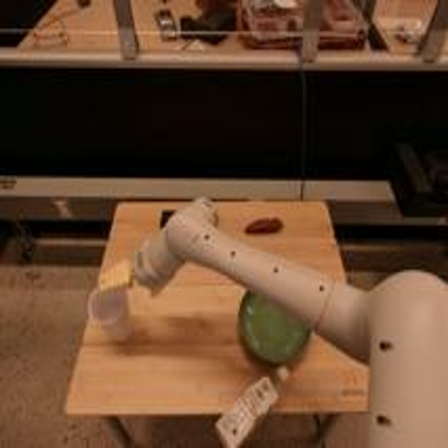

In [66]:
sample['image'][0]

In [67]:
inputs = processor.apply_chat_template(
    [sample['messages'][0]],
    add_generation_prompt = True,
    tokenize = True,
    enable_thinking = False,
    return_dict = True,
    return_tensors = "pt"
).to(model.device)

In [68]:
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens = 4096
    )

In [69]:
print(processor.tokenizer.decode(output[0]))

<|im_start|>user
<|vision_start|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|ima

In [54]:
output[0]

tensor([248045,    846,    198, 248053, 248056, 248056, 248056, 248056, 248056,
        248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056,
        248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056,
        248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056,
        248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056,
        248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056,
        248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056,
        248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056,
        248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056,
        248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056,
        248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056,
        248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056, 248056,
        248056, 248056, 248056, 248056, 

In [55]:
processor.tokenizer.decode(25)

':'

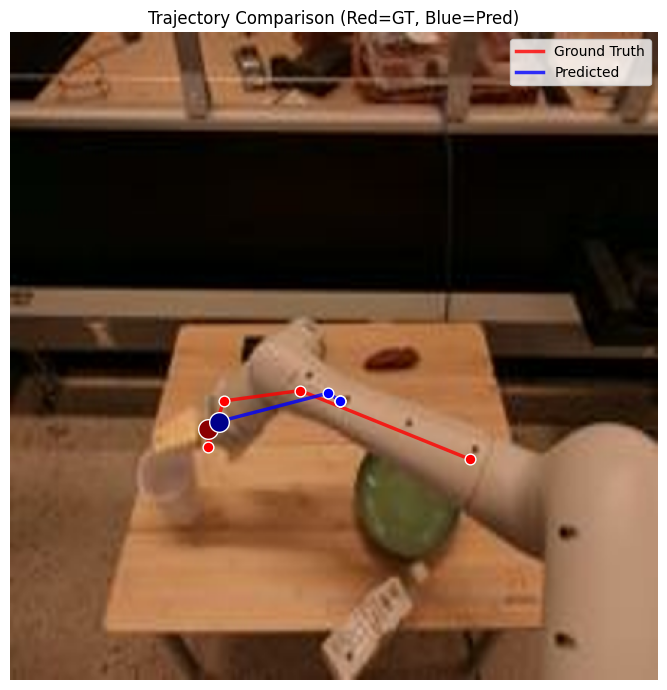

In [17]:
visualize_trajectory_comparison(train_dataset[1], "[[321, 600],[490, 556],[509, 568],[509, 568],[509, 568]]")

In [16]:
import matplotlib.pyplot as plt
import ast
import numpy as np

def visualize_trajectory_comparison(sample, predicted_coords=None):
    """
    Visualizes Ground Truth (Red) vs Predicted (Blue) 2D waypoints.
    
    Args:
        sample: A dictionary from your VLAStaticDataset
        predicted_coords: A list of [[x,y],...] or a string "[[x,y],...]". 
                          If None, it only plots the ground truth.
    """
    # 1. Get the image
    image = sample["image"][0]
    img_w, img_h = image.size
    
    # 2. Extract Ground Truth from the sample
    messages = sample["messages"]
    assistant_text = next(msg["content"] for msg in messages if msg["role"] == "assistant")
    
    try:
        gt_coords_1000 = ast.literal_eval(assistant_text)
    except (ValueError, SyntaxError):
        print(f"Failed to parse ground truth from: {assistant_text}")
        return

    # Helper function to scale coordinates
    def scale_coords(coords):
        scaled = []
        for x, y in coords:
            scaled_x = (x / 1000.0) * img_w
            scaled_y = (y / 1000.0) * img_h
            scaled.append((scaled_x, scaled_y))
        return np.array(scaled)

    # Scale Ground Truth
    gt_scaled = scale_coords(gt_coords_1000)

    # 3. Setup Plot
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(image)
    
    # --- Plot Ground Truth (RED) ---
    ax.plot(gt_scaled[:, 0], gt_scaled[:, 1], 
            color='red', linewidth=2.5, alpha=0.8, label='Ground Truth')
    ax.scatter(gt_scaled[:, 0], gt_scaled[:, 1], 
               color='red', s=60, zorder=5, edgecolors='white')
    
    # Mark GT Start
    ax.scatter(gt_scaled[0, 0], gt_scaled[0, 1], 
               color='darkred', s=200, zorder=6, edgecolors='white')

    # --- Plot Predicted (BLUE) ---
    if predicted_coords is not None:
        if isinstance(predicted_coords, str):
            try:
                predicted_coords = ast.literal_eval(predicted_coords)
            except:
                print("Failed to parse predicted_coords string.")
                predicted_coords = []
                
        if len(predicted_coords) > 0:
            pred_scaled = scale_coords(predicted_coords)
            ax.plot(pred_scaled[:, 0], pred_scaled[:, 1], 
                    color='blue', linewidth=2.5, alpha=0.8, label='Predicted')
            ax.scatter(pred_scaled[:, 0], pred_scaled[:, 1], 
                       color='blue', s=60, zorder=5, edgecolors='white')
            
            # Mark Pred Start
            ax.scatter(pred_scaled[0, 0], pred_scaled[0, 1], 
                       color='darkblue', s=200, zorder=6, edgecolors='white')

    ax.set_title("Trajectory Comparison (Red=GT, Blue=Pred)")
    ax.axis('off')
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# --- Example Usage ---

# 1. To just plot Ground truth:
# visualize_trajectory_comparison(train_dataset[0])

# 2. To plot Ground truth + your Model's Prediction:
# my_prediction = "[[100, 200], [150, 250], [200, 300], [250, 350], [300, 400]]"
# visualize_trajectory_comparison(train_dataset[0], predicted_coords=my_prediction)
